Hola **Daniel**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>


Puedes responderme de esta forma:

<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 
</div>


# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# cargar archivos
orders_raw = pd.read_csv("rappiplus_orders_raw.csv")
catalog_raw = pd.read_csv("rappiplus_catalog.csv")
marketing_raw = pd.read_csv("rappiplus_marketing_spend.csv")

In [3]:
# explorar datasets
orders_raw.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


In [4]:
catalog_raw.head()

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


In [5]:
marketing_raw.head()

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [6]:
# Revisión inicial de la información general del dataframe "orders"
orders_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [7]:
# Validación y corrección de fechas al tipo de dato correcto
orders_raw['fecha_hora_pedido']=pd.to_datetime(orders_raw['fecha_hora_pedido'])

In [8]:
# Validación de nulos en columna "país"
paises=orders_raw['pais'].unique()
print(paises)

['Argentina' 'Mexico' 'Colombia' 'mexico' 'colombia' 'argentina' nan]


In [9]:
# Corrección de escritura de variables
correcciones={'mexico':'Mexico', 'colombia':'Colombia', 'argentina':'Argentina'}
orders_raw['pais']=orders_raw['pais'].replace(correcciones)
print(orders_raw['pais'].unique())

['Argentina' 'Mexico' 'Colombia' nan]


In [10]:
# Conteo de nulos en "pais"
nulos_pais=orders_raw['pais'].isna().sum()
print(nulos_pais)

300


- En todas las categorias observamos que hay un porcentaje muy bajo de nulos lo que no nos representa gran pérdida de información. Se decide eliminar los datos nulos.

In [11]:
# Eliminación de datos nulos
orders_raw=orders_raw.dropna()
orders_raw.head()

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


- En total vemos que se perdieron 400 filas, lo que representa el 1.59% de los datos originales, no es algo estadísticamente significativo. 

In [12]:
# Corrección de tipo de valor de cantidad a enteros
orders_raw['cantidad']=orders_raw['cantidad'].astype('int64')

In [13]:
# Revisión final de la información general del dataframe "orders"
orders= orders_raw
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 24700 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24700 non-null  object        
 1   id_usuario          24700 non-null  object        
 2   fecha_hora_pedido   24700 non-null  datetime64[ns]
 3   pais                24700 non-null  object        
 4   dispositivo         24700 non-null  object        
 5   fuente_referencia   24700 non-null  object        
 6   nombre_producto     24700 non-null  object        
 7   categoria_producto  24700 non-null  object        
 8   cantidad            24700 non-null  int64         
 9   precio_unitario     24700 non-null  float64       
 10  monto_descuento     24700 non-null  float64       
 11  monto_total         24700 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 2.4+ MB


In [14]:
# Revisión inicial de la información general del dataframe "catalog"
catalog_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [15]:
# Verificación de duplicados
print(catalog_raw['nombre_producto'].unique())
print()
print(catalog_raw['categoria_producto'].unique())
print()
print(catalog_raw['proveedor'].unique())

['Laptop-Gaming-16GB' 'Phone-Pro-128GB' 'Tablet-Standard-64GB'
 'Blender-XL-Red' 'Vacuum-Pro-Black' 'Sneakers-Urban-42' 'Jacket-Winter-M']

['Electrónica' 'Hogar' 'Moda']

['Fuller, Pena and Myers' 'King Ltd' 'Bowers LLC' 'Long-Reid'
 'Rivera, Carr and Finley' 'Greene-Smith' 'Mcmillan-Rhodes']


- En este dataframe no se encuentran datos para corregir, no hay presencia de valores nulos y los tipos de datos se respetan de acuerdo a lo que deben de ser para cada variable.

In [16]:
# Revisión inicial de la información general del dataframe "marketing"
marketing_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [17]:
# Correción del tipo de dato de la columna "fecha"
marketing_raw['fecha']= pd.to_datetime(marketing_raw['fecha'])

In [18]:
# Verificación de valores nulos en la columna "canal"
print(marketing_raw['canal'].unique())
print(marketing_raw['canal'].isna().sum())

['organic' 'paid_search' 'social' nan]
101


- Se documenta que hay 101 valores nulos en la columna de 'canal', lo cual representa el 6.23% de los datos de este dataframe por lo que se decide tambien elimnar esas filas para no generar información errónea.

In [19]:
# Eliminación de los valores nulos del dataframe "marketing"
marketing=marketing_raw.dropna()

In [20]:
#Revisión final de la información general del dataframe "marketing"
marketing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1519 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1519 non-null   datetime64[ns]
 1   pais        1519 non-null   object        
 2   id_campaña  1519 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1519 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 71.2+ KB


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [21]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog_raw.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [22]:
# Importación de los dataframes corregidos
orders=pd.read_csv("orders_clean.csv")
catalog=pd.read_csv("catalog_clean.csv")
marketing=pd.read_csv("marketing_clean.csv")

In [23]:
# Cálculo del ingreso total (revenue)
ingreso_total= orders['monto_total'].sum()
print(f'El ingreso total percibido de los pedidos es de: ${ingreso_total:.2f}')

El ingreso total percibido de los pedidos es de: $51873170.44


In [24]:
# Unión de dataframe "orders" y "catalog"
resultado=orders.merge(catalog, on="nombre_producto")


In [25]:
# Creación de columna "costo_total_venta"
resultado['costo_total_venta']=resultado['cantidad']*resultado['costo_unitario']

In [26]:
# Cálculo del costo total
costo_total=resultado['costo_total_venta'].sum()
print(f'El costo total de compra de productos fue de: ${costo_total:.2f}')

El costo total de compra de productos fue de: $43095280.85


In [27]:
# Cálculo de costo de marketing
costo_marketing=marketing['gasto'].sum()
print(f'El gasto total en marketing fue de: ${costo_marketing:.2f}')

El gasto total en marketing fue de: $2694664.43


In [28]:
# Cálculo de ganancia
ganancia=ingreso_total-(costo_total+costo_marketing)
print(f'La ganancia total del negocio fue de: ${ganancia:.2f}')

La ganancia total del negocio fue de: $6083225.16


**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?  El ingreso total percibido de los pedidos es de: 51873170.44.
- ¿Cuál es el costo total? El costo total de compra de productos fue de: 43095280.85
- ¿Cuánto se ha invertido en marketing? El gasto total en marketing fue de: 2694664.43
- ¿El negocio es rentable? (calcular ganancia) La ganancia total del negocio fue de: $6083225.16, lo que indicaría que si es rentable el negocio inicialmente.


In [29]:
# Cálculo de número total de ordenes
numero_ordenes=orders['id_pedido'].count()
print(f'El número de ordenes totales es de: {numero_ordenes}')

El número de ordenes totales es de: 24700


In [30]:
# Cálculo de ticket promedio por orden
ticket_promedio=ingreso_total/numero_ordenes
print(f'El ticket promedio por orden es de: ${ticket_promedio:.2f}')

El ticket promedio por orden es de: $2100.13


In [31]:
# Cálculo de cantidad de productos vendidos en total
cantidad_productos_vendidos=orders['cantidad'].sum()
print(f'Se vendieron en un total de productos de: {cantidad_productos_vendidos}')

Se vendieron en un total de productos de: 177164


In [32]:
# Cálculo de cantidad promedio de productos por orden
productos_promedio=cantidad_productos_vendidos/numero_ordenes
print(f'La cantidad promedio de productos por orden es de: {productos_promedio:.2f}')

La cantidad promedio de productos por orden es de: 7.17


In [33]:
# Creación de tabla "ventas_por_producto"
ventas_por_producto= orders.groupby('nombre_producto')['cantidad'].sum()
print(ventas_por_producto)

nombre_producto
Blender-XL-Red            6210
Jacket-Winter-M           6210
Laptop-Gaming-16GB      144181
Phone-Pro-128GB           4100
Sneakers-Urban-42         6103
Tablet-Standard-64GB      4124
Vacuum-Pro-Black          6236
Name: cantidad, dtype: int64


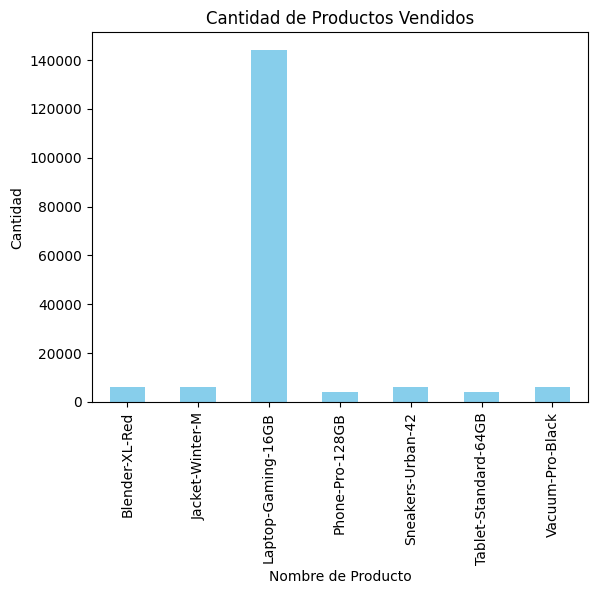

In [34]:
# Representación gráfica de "ventas_por_producto"
ventas_por_producto.plot(kind='bar', x='nombre_producto', y='Cantidad', color='skyblue', legend=False)
plt.title('Cantidad de Productos Vendidos')
plt.xlabel('Nombre de Producto')
plt.ylabel('Cantidad')

plt.show()

**Interpretación** 
- Como podemos observar el gráfico de barras previo muestra que el producto más vendido es la Laptop-Gaming-16GB.
- Adicionalmente podemos observar que los dos productos menos vendidos son el Phone-Pro-128GB y la Tablet-Standard-64GB. 

In [35]:
# Identificación del producto más vendido
print(f'El producto más vendido fue {ventas_por_producto.idxmax()} con {ventas_por_producto.max()} unidades vendidas')

El producto más vendido fue Laptop-Gaming-16GB con 144181 unidades vendidas


In [36]:
# Creación de tabla de gastos por canal
gasto_por_canal=marketing.groupby('canal')['gasto'].sum()
print(gasto_por_canal)

canal
organic        913533.01
paid_search    863088.21
social         918043.21
Name: gasto, dtype: float64


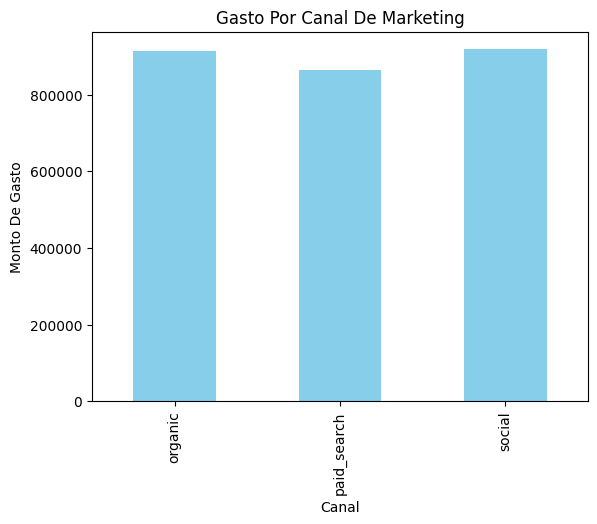

In [37]:
# Representación gráfica de "gastos por canal"
gasto_por_canal.plot(kind='bar', x='canal', y='gasto', color='skyblue', legend=False)
plt.title('Gasto Por Canal De Marketing')
plt.xlabel('Canal')
plt.ylabel('Monto De Gasto')

plt.show()

**Interpretación**
- Se observa un gráfico de barras donde observamos los gastos totales en cada canal de marketing utilizado por la empresa.
- Podemos observar que el canal con mayor gasto es el "social", seguido del "organic" y teniendo el menor gasto en las "paid_search".

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? El ticket promedio por orden es de: 2100.13
- ¿Cuál es la cantidad promedio de productos por orden? La cantidad promedio de productos por orden es de: 7.17
- ¿Cuál es el producto más vendido? El producto más vendido fue Laptop-Gaming-16GB con 144181 unidades vendidas


**COMENTARIO DE INTERPRETACIONES FINALES**
- Observando nuestros KPIs iniciales podemos concluir que la empresa está generando redituabilidad significativa al observar una ganancia de $6083225.16, lo cual sería una retención de 11.73% de los ingresos totales generados por las ventas como ganancias para la empresa. Valdría la pena comparar con años previos para tener una perspectiva de si hay un crecimiento en cuanto a las ganancias este año.
- En cuanto a los productos vendidos, se puede observar que el producto más vendido es la Laptop-Gaming-16GB, valdría la pena revisar que tecnicas de marketing, ofertas o programas se están utilizando para generar esas ventas y poder implementar esas mismas en los demás productos cuando sea posible para poder incrementar sus ventas.
- En cuanto al gasto generado en marketing valdría la pena revisar a detalle que cantidad de ventas se han generado por fuente de marketing con el objetivo de ver si es correcto el continuar con el mayor gasto en "social". 

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 lo ideal sería agregar las gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos.

Pero para complementar esta parte también puedes agregar tu interpretación de las gráficas mostradas en una celda markdown.

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre es importante tener un proceso de análisis claro y fácil de entender en todos tus notebooks para que cuando alguien de tu equipo quiera reproducir tu trabajo puedan entenderlo facilmente.
</div>

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [38]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [39]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [40]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT nombre_evento, COUNT(DISTINCT id_usuario) AS usuarios_unicos 
FROM events 
GROUP BY nombre_evento
ORDER BY 
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'select_item' THEN 2
        WHEN 'add_to_cart' THEN 3
        WHEN 'begin_checkout' THEN 4
        WHEN 'add_payment_info' THEN 5
        WHEN 'purchase' THEN 6
    END
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,select_item,7582
2,add_to_cart,7634
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


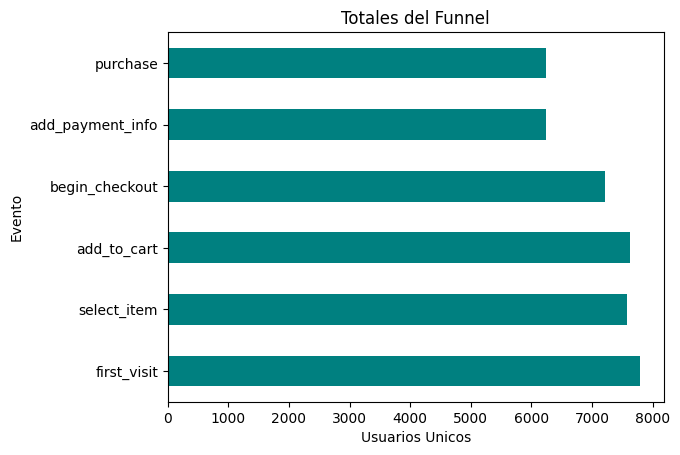

In [41]:
# Representación gráfica de tabla de funnel

ax = totals.plot(kind='barh', x='nombre_evento', y='usuarios_unicos', color='teal', legend=False)
plt.xlabel('Usuarios Unicos')
plt.ylabel('Evento')
plt.title('Totales del Funnel')
plt.show()

**Interpretación**
- Podemos observar un gráfico de barras horizontales con los usuarios totales por cada fase del funnel que siguen en la plataforma. Se observa un descenso progresivo en todos los pasos, a excepción del paso "add_to_cart" donde observamos que incrementan la cantidad de usuarios en una cantidad muy mínima, pero esto puede ser por un registro erroneo de la actividad de los usuarios por parte de la plataforma o los encargados de registros. 

In [42]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
SELECT
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'select_item')*1.0/
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'first_visit')
    AS conversion_first_to_select,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'add_to_cart')*1.0/
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'first_visit')
    AS conversion_first_to_cart,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'begin_checkout')*1.0/
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'first_visit')
    AS conversion_cart_to_checkout,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'add_payment_info')*1.0/
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'first_visit')
    AS conversion_checkout_to_paymentinfo,
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'purchase')*1.0/
    (SELECT COUNT(DISTINCT id_usuario) FROM events WHERE nombre_evento = 'first_visit')
    AS conversion_end_to_end
'''

conversion = pd.read_sql(query_conversion, con=engine)
print(conversion.to_string(index=False))

 conversion_first_to_select  conversion_first_to_cart  conversion_cart_to_checkout  conversion_checkout_to_paymentinfo  conversion_end_to_end
                    0.97255                   0.97922                     0.924577                            0.801693                0.80041


**COMENTARIO DE INTERPRETACIONES**
- Se observa que hay un incremento de la cantidad de clientes totales entre los pasos 'select_item' y 'add_to_cart', lo que nos podría estar indicando un error en el registro de eventos dentro de la plataforma o error de registro en la base de datos analizada. Lo confirmamos observando que la tasa de conversión entre los pasos es mayor que la tasa de conversión del paso previo ("select_item").
- En las etapas donde se pierden más usuarios es en la conversión de begin_checkout a add_payment_info, donde se observa una pérdida total de 958 clientes.
- Se encuentra que hay una tasa de conversión final de aproximadamente 80%, lo que indica una conversión bastante alta de clientes. 

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>


Aquí hay que revisar el como se calculan las conversiones, debería hacerse en referencia del primer evento más que la conversión de un evento a otro, también habría que revisar el resultado de tu conversión con más del 100% y argumentar o corregir el mismo ya que una conversión no debería tener más del 100%.

También te recomendaría agregar visualizaciones para que exponer los resultados sea más sencillo que solo exponer un resultado numérico.

Para complementar también deberías dejar una celda markdown con tus interpretaciones.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Bien, siempre hay que asegurarse de que las métricas presentadas sean las correctas ya qu eso es vital para una toma de decisiones adecuada en la empresa
</div>

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [43]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [44]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [45]:
# Retención por cohortes
# ======================


query_cohort_retention_final = '''
WITH cohortes AS (SELECT id_usuario, DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohorte
FROM users),
actividad AS (SELECT id_usuario, MAX(CASE WHEN dias_despues_registro BETWEEN 1 AND 7 AND activo = 1 THEN 1 ELSE 0 END) AS semana1,
MAX(CASE WHEN dias_despues_registro BETWEEN 8 AND 14 AND activo = 1 THEN 1 ELSE 0 END) AS semana2, 
MAX(CASE WHEN dias_despues_registro BETWEEN 15 AND 21 AND activo = 1 THEN 1 ELSE 0 END) AS semana3
FROM user_activity
GROUP BY id_usuario)
SELECT cohortes.cohorte, AVG(actividad.semana1) AS retencion_semana1, AVG(actividad.semana2) AS retencion_semana2, AVG(actividad.semana3) AS retencion_semana3
FROM cohortes
JOIN actividad ON cohortes.id_usuario = actividad.id_usuario
GROUP BY cohortes.cohorte
ORDER BY cohortes.cohorte
'''


# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte,retencion_semana1,retencion_semana2,retencion_semana3
0,2025-01-01 00:00:00+00:00,0.428396,0.410572,0.403196
1,2025-02-01 00:00:00+00:00,0.423130,0.421745,0.439751
2,2025-03-01 00:00:00+00:00,0.413814,0.430929,0.421760
3,2025-04-01 00:00:00+00:00,0.423412,0.433998,0.412827
4,2025-05-01 00:00:00+00:00,0.411974,0.400711,0.418494


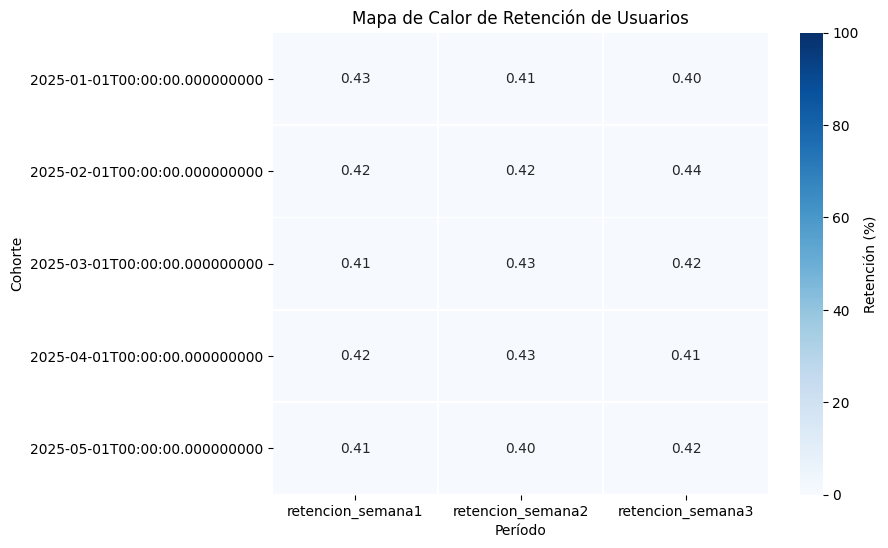

In [46]:
# Visualización con heatmap de retenciones de usuarios
tabla = cohorte_final.set_index('cohorte')

plt.figure(figsize=(8, 6))
sns.heatmap(
    tabla,
    annot=True,  
    fmt=".2f",  
    cmap="Blues",  
    vmin=0,
    vmax=100,  
    linewidths=0.5,  
    cbar_kws={"label": "Retención (%)"},
)
plt.title("Mapa de Calor de Retención de Usuarios")
plt.xlabel("Período")
plt.ylabel("Cohorte")
plt.show()

**COMENTARIOS E INTERPRETACIONES**
- Podemos observar que la tasa de retención independientemente del cohorte se mantiene casi igual a lo largo del periodo evaluado, valdría la pena hacer una revisión de ofertas, programas de fidelidad o el marketing que se está haciendo a los clientes ya registrados para aumentar su tasa de retención en la plataforma.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La query está muy bien y estás obteniendo resultados adecuados pero lo complementarías mejor si agregaras una visualización.
</div>

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hubo un cambio en la proporción de conversiones entre los grupos control y tratamiento. 
   - **H₁ (Hipótesis alternativa):** Si hay una variación en la proporción de conversiones entre los grupos control y tratamiento. 
   
**Test estadístico:** Chi-cuadrado de independencia  
**Nivel de significancia alpha:** 0.05

In [47]:
# Cargar archivo
experiment = pd.read_csv("experiment_checkout_ui.csv")
experiment.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [48]:
# Creación de tabla de contingencia
contingencia = pd.crosstab(experiment['variante'], experiment['convirtio'])
contingencia

convirtio,0,1
variante,,
control,4186,779
tratamiento,4215,820


In [49]:
import pandas as pd
from scipy.stats import chi2_contingency

chi2_stat, p_value, dof, expected = chi2_contingency(contingencia)
print(f"\nEstadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")



Estadístico chi-cuadrado: 0.618
Valor P: 0.432


**Conclusión:**
- De acuerdo al test de Chi-Cuadrado encontramos un valor P (0.432) mayor al alpha (0.05) previamente establecido, lo que nos indica que los resultados podrían verse asociados al azar y no con cambios reales por los cambios aplicados a la plataforma. Se sugiere mayor evaluación antes de aplicar los cambios, pues hasta este momento no se ha demostrado que generen cambios estadísticamente significativos.

---

**COMENTARIO Y RECOMENDACIONES FINALES**
- Pese al valor alto de ganancias observado en los KPI del periodo evaluado, recomiendo un análisis comparativo con años previos para evaluar que tanto ha crecido o disminuido las ganancias de la plataforma.
- De igual manera se recomienda realizar una evaluación de las técnicas utilizadas por el departamento de computo para incrementar las ventas de su producto la Laptop-Gaming-16GB y ver, dentro de las posibilidades, de implementar medidas similares en los otros departamentos para aumentar las ventas de los demás productos.
- En cuanto al costo de marketing valdría la pena analizar que canal de marketing está generando mayor número de ventas y, de tal manera, priorizar los costos con la finalidad de incrementar las ventas y, por tanto, las ganancias. Adicionalmente recomiendo un análisis comparativo de costos de marketing de este periodo contra previos para observar si hay un cambio en los gastos que este departamento este generando.
- Observando la tasa de conversión y las tasas de retención podemos concluir que la empresa está teniendo una adecuada primera interacción con los clientes, se generan primeras ventas, ahora valdría la pena investigar donde está el fallo de la retención del cliente posteriormente a la primera compra. Se recomienda evaluar programas de fidelidad, ofertas o campañas específicas para clientes ya registrados de la plataforma.
- Finalmente, en cuanto a los cambios realizados en el experimento, podría recomendar no realizar los cambios de momento, pues de acuerdo a los resultados de la prueba Chi-Cuadrado estos pueden ser netamente relacionados al azar y no necesariamente beneficiosos para la empresa. Por lo que habrá que hacer mayor evaluación de los sugeridos cambios.

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

# link de google drive
https://drive.google.com/drive/folders/1Vb-06Bb-YIFZ9O7hCy77qtpdyyEa-MhS?usp=sharing

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto Daniel. Hay algunos puntos con oportunidades de mejora donde te he dejado algunos comentarios.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.


Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Daniel!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>